In [19]:
from collections import deque
import spot

# Reuse the structural LTLMutator class we refined in the previous step
# class LTLMutator:
#     def __init__(self, ap_list):
#         self.ap_set = set(ap_list)
#         self.aps = [spot.formula.ap(p) for p in self.ap_set]
#         self.unary_ops = {
#             spot.op_Not: spot.formula.Not, spot.op_X: spot.formula.X,
#             spot.op_F: spot.formula.F, spot.op_G: spot.formula.G
#         }
#         self.binary_ops = {
#             spot.op_U: spot.formula.U, spot.op_R: spot.formula.R, spot.op_W: spot.formula.W,
#             spot.op_And: lambda a, b: spot.formula.And([a, b]),
#             spot.op_Or: lambda a, b: spot.formula.Or([a, b])
#         }
#         self.rule3d_ops = {
#             'U': spot.formula.U, 'W': spot.formula.W,
#             '&': lambda a, b: spot.formula.And([a, b]), '|': lambda a, b: spot.formula.Or([a, b])
#         }

#     def mutate(self, phi):
#         if isinstance(phi, str):
#             phi = spot.formula(phi)
#         phi = phi.unabbreviate("ie")
#         mutations = {}
#         for mut_f in self._mutate_recursive(phi, is_top_level=True):
#             s = mut_f.to_str()
#             if s not in mutations:
#                 mutations[s] = mut_f
#         orig_s = phi.to_str()
#         if orig_s in mutations:
#             del mutations[orig_s]
#         return list(mutations.values())

#     def _mutate_recursive(self, f, is_top_level=True):
#         for op_func in self.unary_ops.values():
#             yield op_func(f)
            

#         if f.is_ff() or f in self.ap_set: yield spot.formula.tt()
#         if f.is_tt() or f in self.ap_set: yield spot.formula.ff()

#         if f in self.ap_set:
#             for p in self.aps:
#                 if p != f: yield p
        
#         if not is_top_level or f in self.ap_set or f.is_tt() or f.is_ff():
#             for p in self.aps: yield p

#         kind = f.kind()
#         if kind in self.unary_ops:
#             child = f[0]
#             for other_kind, op_func in self.unary_ops.items():
#                 if other_kind != kind: yield op_func(child)
#             yield child
#             for mutated_child in self._mutate_recursive(child, is_top_level=False):
#                 yield self.unary_ops[kind](mutated_child)
#             for p in self.aps:
#                 for op_func in self.rule3d_ops.values(): yield op_func(p, f)
                    
#         elif kind in self.binary_ops:
#             children = list(f)
#             if len(children) >= 2:
#                 phi_1 = children[0]
#                 phi_2 = spot.formula.And(children[1:]) if kind == spot.op_And else (spot.formula.Or(children[1:]) if kind == spot.op_Or else children[1])
                    
#                 for other_kind, op_func in self.binary_ops.items():
#                     if other_kind != kind: yield op_func(phi_1, phi_2)
#                 yield phi_1
#                 yield phi_2
#                 for mutated_left in self._mutate_recursive(phi_1, is_top_level=False):
#                     yield self.binary_ops[kind](mutated_left, phi_2)
#                 for mutated_right in self._mutate_recursive(phi_2, is_top_level=False):
#                     yield self.binary_ops[kind](phi_1, mutated_right)
class LTLMutator:
    def __init__(self, ap_list):
        self.ap_set = set(ap_list)
        self.aps = [spot.formula.ap(p) for p in self.ap_set]
        
        self.unary_ops = {
            spot.op_Not: spot.formula.Not,
            spot.op_X: spot.formula.X,
            spot.op_F: spot.formula.F,
            spot.op_G: spot.formula.G
        }
        
        self.binary_ops = {
            spot.op_U: spot.formula.U,
            spot.op_R: spot.formula.R,
            spot.op_W: spot.formula.W,
            spot.op_And: lambda a, b: spot.formula.And([a, b]),
            spot.op_Or: lambda a, b: spot.formula.Or([a, b])
        }
        
        self.rule3d_ops = {
            'U': spot.formula.U,
            'W': spot.formula.W,
            '&': lambda a, b: spot.formula.And([a, b]),
            '|': lambda a, b: spot.formula.Or([a, b])
        }

    def mutate(self, phi):
        if isinstance(phi, str):
            phi = spot.formula(phi)
            
        phi = phi.unabbreviate("ie")
        mutations = {}
        
        for mut_f in self._mutate_recursive(phi):
            s = mut_f.to_str()
            if s not in mutations:
                mutations[s] = mut_f
                
        orig_s = phi.to_str()
        if orig_s in mutations:
            del mutations[orig_s]
            
        return list(mutations.values())

    def _mutate_recursive(self, f):
        # --- GENERAL CASES ---
        for op_func in self.unary_ops.values():
            print(f"Applying unary operator: {op_func,f, op_func(f)}")
            yield op_func(f)
            
        # yield spot.formula.tt()
        # yield spot.formula.ff()
        # for p in self.aps:
        #     yield p
            
        kind = f.kind()
        
        # --- BASE CASES ---
        if f.is_tt() or f.is_ff():
            yield spot.formula.ff()
        if f.is_ff():
            yield spot.formula.tt()
            
        if f in self.ap_set:
            for p in self.aps:
                if p != f:
                    yield p
                    
        # --- INDUCTIVE CASES ---
        if kind in self.unary_ops:
            child = f[0]
            
            # 3(a) Change unary operator
            for other_kind, op_func in self.unary_ops.items():
                if other_kind != kind:
                    yield op_func(child)
                    
            # 3(b) Drop operator
            yield child
            
            # 3(c) Mutate child -> CRITICAL FIX: Added 'yield from'
            for mutated_child in self._mutate_recursive(child):
                yield self.unary_ops[kind](mutated_child)
                
            # 3(d) Append binary operator
            for p in self.aps:
                for op_func in self.rule3d_ops.values():
                    yield op_func(p, f)
                    
        elif kind in self.binary_ops:
            children = list(f)
            
            if len(children) >= 2:
                phi_1 = children[0]
                if len(children) > 2:
                    if kind == spot.op_And:
                        phi_2 = spot.formula.And(children[1:])
                    elif kind == spot.op_Or:
                        phi_2 = spot.formula.Or(children[1:])
                    else:
                        phi_2 = children[1]
                else:
                    phi_2 = children[1]
                    
                # 4(a) Change binary operator
                for other_kind, op_func in self.binary_ops.items():
                    if other_kind != kind:
                        yield op_func(phi_1, phi_2)
                        
                # 4(b) Keep one child
                yield phi_1
                yield phi_2
                
                # 4(c) Mutate left child -> CRITICAL FIX: Added 'yield from'
                for mutated_left in self._mutate_recursive(phi_1):
                    yield self.binary_ops[kind](mutated_left, phi_2)
                    
                # 4(d) Mutate right child -> CRITICAL FIX: Added 'yield from'
                for mutated_right in self._mutate_recursive(phi_2):
                    yield self.binary_ops[kind](phi_1, mutated_right)
                    
    def _mutate_recursive(self, f, is_top_level=True):
        # --- GENERAL CASES (Strictly restricted based on your structural goal) ---
        # Rule 5: Wrap the current sub-formula in a unary operator
        for op_func in self.unary_ops.values():
            yield op_func(f)
            
        kind = f.kind()
        
        # --- BASE CASES / LEAF MUTATIONS ---
        # Rule 1 & Rule 6 (Moved here so they only mutate leaves, not the whole tree)
        if f.is_tt():
            yield spot.formula.ff()
            
        if f.is_ff():
            yield spot.formula.tt()
            

        if f in self.ap_set:
            # Rule 2: Swap APs
            for p in self.aps:
                if p != f:
                    yield p
            # Rule 6 for APs: allow mapping an AP to other APs (handled above)
        
        # If we are at the top level of a complex formula, we block Rule 6 
        # from replacing the entire tree with a single 'p' or 'true'.
        # if not is_top_level or f in self.ap_set or f.is_tt() or f.is_ff():
        #     for p in self.aps:
        #         yield p

        # --- INDUCTIVE CASES ---
        if kind in self.unary_ops:
            child = f[0]
            
            # 3(a) Change unary operator
            for other_kind, op_func in self.unary_ops.items():
                if other_kind != kind:
                    yield op_func(child)
                    
            # 3(b) Drop operator
            yield child
            
            # 3(c) Mutate child (Passes is_top_level=False)
            for mutated_child in self._mutate_recursive(child, is_top_level=False):
                yield self.unary_ops[kind](mutated_child)
                
            # 3(d) Append binary operator
            for p in self.aps:
                for op_func in self.rule3d_ops.values():
                    yield op_func(p, f)
                    
        elif kind in self.binary_ops:
            children = list(f)
            
            if len(children) >= 2:
                phi_1 = children[0]
                if len(children) > 2:
                    if kind == spot.op_And:
                        phi_2 = spot.formula.And(children[1:])
                    elif kind == spot.op_Or:
                        phi_2 = spot.formula.Or(children[1:])
                    else:
                        phi_2 = children[1]
                else:
                    phi_2 = children[1]
                    
                # 4(a) Change binary operator
                for other_kind, op_func in self.binary_ops.items():
                    if other_kind != kind:
                        yield op_func(phi_1, phi_2)
                        
                # 4(b) Keep one child
                yield phi_1
                yield phi_2
                
                # 4(c) Mutate left child (Passes is_top_level=False)
                for mutated_left in self._mutate_recursive(phi_1, is_top_level=False):
                    yield self.binary_ops[kind](mutated_left, phi_2)
                    
                # 4(d) Mutate right child (Passes is_top_level=False)
                for mutated_right in self._mutate_recursive(phi_2, is_top_level=False):
                    yield self.binary_ops[kind](phi_1, mutated_right)

class LTLMutationDistance:
    def __init__(self, ap_list):
        """
        Initialize the distance calculator with the allowed atomic propositions.
        """
        self.mutator = LTLMutator(ap_list)

    def calculate_distance(self, source, target):
        """
        Calculates the minimum mutation distance from source formula to target formula.
        
        :param source: Starting LTL formula string (e.g., "G(p U q)")
        :param target: Destination LTL formula string (e.g., "p U !q")
        :return: (int, list) The distance, and the step-by-step path taken. Returns (inf, []) if unreachable.
        """
        src_formula = spot.formula(source).unabbreviate("ie")
        tgt_formula = spot.formula(target).unabbreviate("ie")
        
        src_str = src_formula.to_str()
        tgt_str = tgt_formula.to_str()
        
        if src_str == tgt_str:
            return 0, [src_str]
            
        # BFS Queue holds tuples of (current_formula, path_taken_as_list)
        queue = deque([(src_formula, [src_str])])
        
        # Visited set tracks string representations to prevent infinite loops
        visited = {src_str}
        
        while queue:
            current_formula, current_path = queue.popleft()
            
            # Generate all valid 1-point mutations from the current formula
            neighbors = self.mutator.mutate(current_formula)
            
            for neighbor in neighbors:
                neighbor_str = neighbor.to_str()
                
                if neighbor_str == tgt_str:
                    return len(current_path), current_path + [neighbor_str]
                    
                if neighbor_str not in visited:
                    visited.add(neighbor_str)
                    queue.append((neighbor, current_path + [neighbor_str]))
                    
        return float('inf'), [] # If no structural mutation path connects them

In [20]:
# 1. Define the pool of atomic propositions used in your system
ap_pool = ['p', 'q']

# 2. Instantiate the Mutator
mutator = LTLMutator(ap_pool)

# 3. Supply the base LTL formula you wish to mutate
original_formula = "G(p U q)"
mutations = mutator.mutate(original_formula)

print(f"Original Formula: {original_formula}")
print(f"Total Unique Mutations Found: {len(mutations)}")
print("-" * 30)

# 4. Display the results
for i, m in enumerate(mutations):
    print(f"{i + 1:02d}: {m.to_str()}")

Original Formula: G(p U q)
Total Unique Mutations Found: 32
------------------------------
01: !G(p U q)
02: XG(p U q)
03: FG(p U q)
04: !(p U q)
05: X(p U q)
06: F(p U q)
07: p U q
08: G!(p U q)
09: GX(p U q)
10: GF(p U q)
11: G(p R q)
12: G(p W q)
13: G(p & q)
14: G(p | q)
15: Gp
16: Gq
17: G(!p U q)
18: G(Xp U q)
19: G(Fp U q)
20: G(Gp U q)
21: G(p U !q)
22: G(p U Xq)
23: G(p U Fq)
24: G(p U Gq)
25: q U G(p U q)
26: q W G(p U q)
27: q & G(p U q)
28: q | G(p U q)
29: p U G(p U q)
30: p W G(p U q)
31: p & G(p U q)
32: p | G(p U q)


In [21]:
# Define the AP pool
ap_pool = ['p', 'q']
dist_calculator = LTLMutationDistance(ap_pool)

# Define source and destination formulas
start = "GF(p U q)"
end = "p U !(q->p)"

distance, path = dist_calculator.calculate_distance(start, end)

print(f"Source: {start}")
print(f"Target: {end}")
print(f"Mutation Distance: {distance}")
print("Optimal Mutation Path:")
print(" |-> ".join(path))

Source: GF(p U q)
Target: p U !(q->p)
Mutation Distance: 5
Optimal Mutation Path:
GF(p U q) |-> !F(p U q) |-> p U q |-> p U !q |-> p U (p | !q) |-> p U !(p | !q)


In [13]:
f_node = spot.formula("!GF(p U q)")
f_node.to_str()

'!GF(p U q)'

In [14]:
ap_pool = ['p', 'q']

# 2. Instantiate the Mutator
mutator = LTLMutator(ap_pool)

# 3. Supply the base LTL formula you wish to mutate
original_formula = "!GF(p U q)"
mutations = mutator.mutate(original_formula)

print(f"Original Formula: {original_formula}")
print(f"Total Unique Mutations Found: {len(mutations)}")
print("-" * 30)

# 4. Display the results
for i, m in enumerate(mutations):
    print(f"{i + 1:02d}: {m.to_str()}")

Original Formula: !GF(p U q)
Total Unique Mutations Found: 61
------------------------------
01: GF(p U q)
02: X!GF(p U q)
03: F!GF(p U q)
04: G!GF(p U q)
05: XGF(p U q)
06: FGF(p U q)
07: !XGF(p U q)
08: !FGF(p U q)
09: !q
10: !p
11: F(p U q)
12: !XF(p U q)
13: !F(p U q)
14: !G!F(p U q)
15: !GXF(p U q)
16: !Gq
17: !Gp
18: !G!(p U q)
19: !GX(p U q)
20: !G(p U q)
21: !GF!(p U q)
22: !GFX(p U q)
23: !GFG(p U q)
24: !GFq
25: !GFp
26: !GF(p R q)
27: !GF(p W q)
28: !GF(p & q)
29: !GF(p | q)
30: !GF(!p U q)
31: !GF(Xp U q)
32: !GF(Fp U q)
33: !GF(Gp U q)
34: !GF(p U !q)
35: !GF(p U Xq)
36: !GF(p U Fq)
37: !GF(p U Gq)
38: !G(q U F(p U q))
39: !G(q W F(p U q))
40: !G(q & F(p U q))
41: !G(q | F(p U q))
42: !G(p U F(p U q))
43: !G(p W F(p U q))
44: !G(p & F(p U q))
45: !G(p | F(p U q))
46: !(q U GF(p U q))
47: !(q W GF(p U q))
48: !(q & GF(p U q))
49: !(q | GF(p U q))
50: !(p U GF(p U q))
51: !(p W GF(p U q))
52: !(p & GF(p U q))
53: !(p | GF(p U q))
54: q U !GF(p U q)
55: q W !GF(p U q)
56: q &

In [ ]:
from collections import deque
import spot

class LTLTree:
    """A pure, un-optimized Abstract Syntax Tree (AST) for LTL formulas."""
    def __init__(self, value, children=None):
        self.value = value  # e.g., 'G', 'F', '!', 'U', '&', 'p', 'q'
        self.children = children if children is not None else []

    @classmethod
    def from_spot(cls, f):
        """Recursively parses a Spot formula into a pure text AST."""
        kind = f.kind()
        
        if f.is_tt(): return cls("true")
        if f.is_ff(): return cls("false")
        
        # Check if Atomic Proposition
        if kind == spot.op_ap: 
            return cls(f.to_str())
        
        # Handle Unary Operators
        if kind in [spot.op_Not, spot.op_X, spot.op_F, spot.op_G]:
            op_str = {spot.op_Not: '!', spot.op_X: 'X', spot.op_F: 'F', spot.op_G: 'G'}[kind]
            return cls(op_str, [cls.from_spot(f[0])])
            
        # Handle Binary/N-ary Operators
        if kind in [spot.op_U, spot.op_R, spot.op_W, spot.op_And, spot.op_Or]:
            op_str = {spot.op_U: 'U', spot.op_R: 'R', spot.op_W: 'W', spot.op_And: '&', spot.op_Or: '|'}[kind]
            children = list(f)
            
            # FIX HERE: Manually fold flat multi-operand structures (e.g., [a, b, c]) 
            # into right-nested binary structures (e.g., (a & (b & c)))
            if len(children) > 2 and kind in [spot.op_And, spot.op_Or]:
                # Start from the last element and build upwards
                right_child = cls.from_spot(children[-1])
                for child in reversed(children[1:-1]):
                    right_child = cls(op_str, [cls.from_spot(child), right_child])
                return cls(op_str, [cls.from_spot(children[0]), right_child])
                
            return cls(op_str, [cls.from_spot(children[0]), cls.from_spot(children[1])])
            
        raise ValueError(f"Unsupported formula component: {f.to_str()}")

    def to_str(self):
        """Converts the tree back to a cleanly parenthesized string format."""
        if not self.children:
            return self.value
        if len(self.children) == 1:
            # Unary operators: e.g., !GF(p U q) -> !(G(F(p U q)))
            child_str = self.children[0].to_str()
            if len(self.value) > 1 or self.value.isalpha() or child_str.startswith('('):
                return f"{self.value}{child_str}"
            return f"{self.value}({child_str})"
        else:
            # Binary operators
            return f"({self.children[0].to_str()} {self.value} {self.children[1].to_str()})"

    def copy(self):
        return LTLTree(self.value, [c.copy() for c in self.children])


class PureLTLMutator:
    def __init__(self, ap_list):
        self.aps = ap_list
        self.unary_ops = ['!', 'X', 'F', 'G']
        self.binary_ops = ['U', 'R', 'W', '&', '|']

    def mutate(self, tree):
        mutations = set()
        for mut_tree in self._mutate_recursive(tree, is_top_level=True):
            mutations.add(mut_tree.to_str())
        orig_str = tree.to_str()
        if orig_str in mutations:
            mutations.remove(orig_str)
        return list(mutations)

    def _mutate_recursive(self, node, is_top_level=True):
        # --- GENERAL CASES ---
        # Rule 5: Wrap in unary operator
        for op in self.unary_ops:
            yield LTLTree(op, [node.copy()])
            
        # Rule 1 & 6: Constants/Leaves (Only at leaf level or structurally allowed)
        if node.value == "true": yield LTLTree("false")
        if node.value == "false": yield LTLTree("true")
        if node.value in ["false"] + self.aps: yield LTLTree("true")
        if node.value in ["true"] + self.aps: yield LTLTree("false")
        
        if node.value in self.aps:
            for p in self.aps:
                if p != node.value: yield LTLTree(p)
                
        if not is_top_level or node.value in (self.aps + ["true", "false"]):
            for p in self.aps:
                yield LTLTree(p)

        # --- INDUCTIVE CASES ---
        if node.value in self.unary_ops:
            child = node.children[0]
            
            # 3(a) Change unary operator
            for op in self.unary_ops:
                if op != node.value: yield LTLTree(op, [child.copy()])
            # 3(b) Drop operator
            yield child.copy()
            # 3(c) Mutate child
            for mut_child in self._mutate_recursive(child, is_top_level=False):
                yield LTLTree(node.value, [mut_child])
            # 3(d) Append binary operator
            for p in self.aps:
                for op in ['U', 'W', '&', '|']:
                    yield LTLTree(op, [LTLTree(p), node.copy()])

        elif node.value in self.binary_ops:
            left, right = node.children[0], node.children[1]
            
            # 4(a) Change binary operator
            for op in self.binary_ops:
                if op != node.value: yield LTLTree(op, [left.copy(), right.copy()])
            # 4(b) Keep one child
            yield left.copy()
            yield right.copy()
            # 4(c) Mutate left child
            for mut_left in self._mutate_recursive(left, is_top_level=False):
                yield LTLTree(node.value, [mut_left, right.copy()])
            # 4(d) Mutate right child
            for mut_right in self._mutate_recursive(right, is_top_level=False):
                yield LTLTree(node.value, [left.copy(), mut_right])


class PureLTLDistanceCalculator:
    def __init__(self, ap_list):
        self.mutator = PureLTLMutator(ap_list)

    def distance(self, start_formula, end_formula):
        # Normalize target string structure via the exact same syntax tree format
        src_tree = LTLTree.from_spot(spot.formula(start_formula))
        tgt_tree = LTLTree.from_spot(spot.formula(end_formula))
        
        src_str = src_tree.to_str()
        tgt_str = tgt_tree.to_str()
        
        if src_str == tgt_str:
            return 0, [src_str]
            
        queue = deque([(src_tree, [src_str])])
        visited = {src_str}
        
        while queue:
            curr_tree, path = queue.popleft()
            neighbors = self.mutator.mutate(curr_tree)
            
            for n_str in neighbors:
                if n_str == tgt_str:
                    return len(path), path + [n_str]
                if n_str not in visited:
                    visited.add(n_str)
                    queue.append((LTLTree.from_spot(spot.formula(n_str)), path + [n_str]))
                    
        return float('inf'), []
    

calc = PureLTLDistanceCalculator(['p', 'q'])
# Note: "q->p" maps syntactically to "!q | p" under standard unabbreviation tree formats
dist, path = calc.distance("GF(p U q)", "p U !( !q | p )")

print(f"Mutation Distance: {dist}")
print("Strict Structural Path:")
for step in path:
    print(f" -> {step}")

Mutation Distance: 5
Strict Structural Path:
 -> GF(p U q)
 -> GF(false U q)
 -> (p U GFq)
 -> (p U G!(q))
 -> (p U G(p | !(q)))
 -> (p U !(p | !(q)))


In [1]:
import spot

# 1. Parse your LTL formula
formula = spot.formula("G(a -> X b)")

# 2. Translate the formula into a Büchi Automaton
aut = formula.translate()

# 3. Find a satisfying run (a lasso)
run = aut.accepting_run()

if run:
    # This prints the handle and the cycle of the lasso
    print("Found a satisfying lasso:", run)
else:
    print("No satisfying lasso exists.")

Found a satisfying lasso: Prefix:
Cycle:
  0
  |  !a



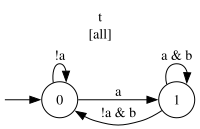

In [2]:
aut

In [4]:
import spot

def count_parameterized_k_lassos(formula_str, k):
    """
    Counts the number of satisfying k-lassos for a given LTL formula.
    k is a natural number parameter limiting the total steps (prefix + loop).
    """
    if k < 1:
        raise ValueError("k must be a natural number greater than 0")

    # 1. Translate the formula to an automaton
    f = spot.formula(formula_str)
    aut = f.translate()
    
    assert aut.is_existential(), "Automaton must be existential/alternating-free"
    
    start_state = aut.get_init_state_number()
    lasso_count = 0
    visited_lassos = set()

    # 2. Bounded DFS exploration
    def dfs(current_state, path, visited_states):
        nonlocal lasso_count
        
        # If the current path length exceeds k, we stop exploring this branch
        if len(path) > k:
            return

        # Check for a loop closure
        if current_state in visited_states:
            loop_start_idx = path.index(current_state)
            prefix = tuple(path[:loop_start_idx])
            loop = tuple(path[loop_start_idx:])
            
            # Total distinct transitions/steps in the lasso = len(prefix) + len(loop)
            # Since path contains the sequence of states up to the repeat, len(path) is our size
            if len(path) <= k:
                lasso_id = (prefix, loop)
                if lasso_id not in visited_lassos:
                    # Verify if the loop satisfies the Büchi acceptance condition
                    if is_loop_accepting(aut, path[loop_start_idx:]):
                        visited_lassos.add(lasso_id)
                        lasso_count += 1
            return

        # Traverse outgoing transitions
        for edge in aut.out(current_state):
            next_state = edge.dst
            
            new_visited = visited_states.copy()
            new_visited.add(current_state)
            
            dfs(next_state, path + [current_state], new_visited)

    def is_loop_accepting(automaton, loop_states):
        # Fix: Call spot.mark_t() directly to initialize an empty acceptance mark
        acc_sets = spot.mark_t() 
        
        for i in range(len(loop_states)):
            src = loop_states[i]
            dst = loop_states[(i + 1) % len(loop_states)]
            
            for edge in automaton.out(src):
                if edge.dst == dst:
                    acc_sets |= edge.acc
                    break
                    
        return automaton.get_acceptance().accepting(acc_sets)

    # Execute search
    dfs(start_state, [], set())
    return lasso_count

# --- Testing the Parameter ---
formula = "F(a) & G(b)"  # Eventually 'a', and 'b' always holds

for parameter_k in range(1, 6):
    count = count_parameterized_k_lassos(formula, k=parameter_k)
    print(f"For k = {parameter_k}, total satisfying lassos: {count}")

For k = 1, total satisfying lassos: 0
For k = 2, total satisfying lassos: 1
For k = 3, total satisfying lassos: 1
For k = 4, total satisfying lassos: 1
For k = 5, total satisfying lassos: 1


In [ ]:
import spot

def count_lasso_bases(formula_str, k):
    """
    Approximates the number of bases w = s0...sk of length k+1
    that can form a lasso trace satisfying the given LTL formula.
    """
    f = spot.formula(formula_str)
    
    # Translate the formula into a deterministic monitor/Büchi automaton
    aut = spot.translate(f, 'ba', 'deterministic')
    
    # Dictionary to keep track of reachable states: {state_id: count_of_paths}
    current_states = {int(aut.get_init_state_number()): 1}
    
    # Track paths of length k (which translates to k+1 states)
    for step in range(k + 1):
        next_states = {}
        for state, path_count in current_states.items():
            for edge in aut.out(state):
                cond = edge.cond
                
                # If the edge condition is false, it's dead/unreachable
                if cond == spot.formula_ff():
                    continue
                
                next_state = int(edge.dst)
                next_states[next_state] = next_states.get(next_state, 0) + path_count
                    
        current_states = next_states

    # Total valid prefixes surviving up to bound k
    return sum(current_states.values())

def semantic_similarity(phi_str, psi_str, k):
    """
    Computes Semantic(phi, psi) = #Approx(phi & psi, k) / #Approx(phi | psi, k)
    """
    and_formula = f"({phi_str}) & ({psi_str})"
    or_formula = f"({phi_str}) | ({psi_str})"
    
    # To find the true set of APs safely, translate the combined formula to an automaton
    # and call .ap() on the automaton object, which returns a list of spot.formula objects
    combined_aut = spot.translate(spot.formula(or_formula), 'ba', 'deterministic')
    variables = [ap.to_str() for ap in combined_aut.ap()]
    
    # Calculate counts
    num_intersection = count_lasso_bases(and_formula, k)
    num_union = count_lasso_bases(or_formula, k)
    
    print(f"Universal variables detected: {variables}")
    print(f"#Approx(φ ∧ ψ, k={k}) = {num_intersection}")
    print(f"#Approx(φ ∨ ψ, k={k}) = {num_union}")
    
    if num_union == 0:
        return 0.0  # Avoid division by zero
        
    return num_intersection / num_union

# --- Example Usage ---
if __name__ == "__main__":
    phi = "G(p -> X(q))"
    psi = "G(p -> F(q))"
    bound_k = 15
    
    similarity = semantic_similarity(phi, psi, bound_k)
    print(f"Semantic Similarity: {similarity:.4f}")

Universal variables detected: ['p', 'q']
#Approx(φ ∧ ψ, k=15) = 65536
#Approx(φ ∨ ψ, k=15) = 65536
Semantic Similarity: 1.0000
